In [8]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from amoc_analysis import data, plotting
from amocatlas import read
from spectra_filtering import analysis, spectra # sonst amocatlas.spectra_filtering


In [9]:
ds = read.mocha()

MOC = ds["MOC"]
MHT = ds["MHT"]
ds

Loading 1 MOCHA 26°N dataset(s):
  0. Johns_2023_mht_data_2020_ERA5.zip: No description available



/Users/jakob/Desktop/SS2026/DataAnalysis/.venv/lib/python3.13/site-packages/amocatlas/reader_utils.py:80: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_dataset(file_path, **kwargs)


<xarray.Dataset> Size: 121MB
Dimensions:               (TIME: 12202, depth: 307)
Coordinates:
  * TIME                  (TIME) datetime64[ns] 98kB 2004-04-02 ... 2020-12-1...
    DEPTH                 (depth) float64 2kB ...
Dimensions without coordinates: depth
Data variables: (12/20)
    Q_eddy                (TIME) float64 98kB 0.0569 0.05509 ... 0.06124 0.06103
    MHT_EKMAN             (TIME) float64 98kB -0.1455 -0.1618 ... 0.7954 0.8344
    MHT_FC                (TIME) float64 98kB 2.154 2.18 2.203 ... 2.335 2.34
    MHT_GYRE              (TIME) float64 98kB 0.1355 0.1346 ... 0.1034 0.1029
    MHT_INT               (TIME) float64 98kB -1.668 -1.665 ... -1.871 -1.87
    MHT_MO                (TIME) float64 98kB -1.414 -1.408 ... -1.702 -1.697
    ...                    ...
    TRANSPROF_FC          (TIME, depth) float64 30MB ...
    TRANSPROF_FC_MEAN     (depth) float64 2kB ...
    TRANS_EKMAN           (TIME) float64 98kB ...
    TRANS_FC              (TIME) float64 98kB ...
    MOC                   (TIME) float64 98kB ...
    STREAMFUNCTION_Z      (TIME, depth) float64 30MB ...
Attributes: (12/40)
    title:                                 MOCHA Heat Transport Data 3/29/200...
    summary:                               Total heat transport results for t...
    program:                               RAPID
    project:                               RAPID-MOCHA
    license:                               ODC-BY
    acknowledgment:                        Funding source: the US National Sc...
    ...                                    ...
    applied_variable_mapping:              {'time': 'TIME', 'maxmoc': 'MOC', ...
    convert_to_coord:                      z
    variables_to_remove:                   ['day', 'hour', 'julian_day', 'mon...
    principal_investigator_url:            http://www.rsmas.miami.edu/people/...
    methodology reference:                 W.E. Johns, S. Elipot, D.A. Smeed,...
    methodology doi:                       doi: 10.1098/rsta.2022.0188

In [14]:
MHT

<xarray.DataArray 'MHT' (TIME: 12202)> Size: 98kB
array([0.59404888, 0.61045301, 0.62482702, ..., 1.37868624, 1.42841637,
       1.47767741], shape=(12202,))
Coordinates:
  * TIME     (TIME) datetime64[ns] 98kB 2004-04-02 ... 2020-12-14T12:00:00
Attributes:
    long_name:      MHT
    units:          PW
    description:    Net meridional heat transport\n
    standard_name:  northward_ocean_heat_transport

In [10]:
# freq, psd = spectra.raw_periodogram(MOC, dt_days = 0.5)
# freq2, psd2 = spectra.welch_psd(MOC,dt_days = 0.5,overlap = 0.5, segment_length=365*5, window = "hann", mode = "zero-padding")

freq, psd = spectra.raw_periodogram(MHT, dt_days = 0.5)
freq2, psd2 = spectra.welch_psd(MHT,dt_days = 0.5,overlap = 0.5, segment_length=365*5, window = "hann", mode = "zero-padding")

Used zero-padding for last segment. Padded 567 zeros.


In [11]:
spectra.parseval_ratio(MHT,freq,psd)

0.9957773943358511

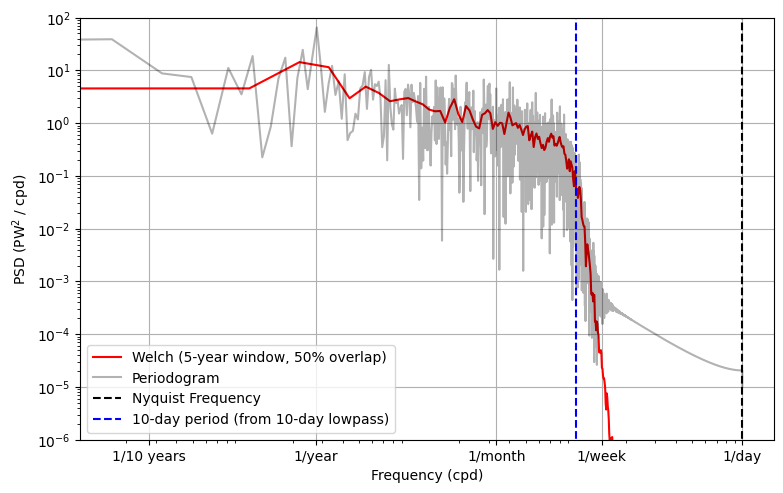

In [13]:
plt.figure(figsize=[8,5])
plt.loglog(freq2,psd2, color = "red", label = "Welch (5-year window, 50% overlap)")
plt.loglog(freq,psd, color = "k", alpha = 0.3, label = "Periodogram")
plt.grid()
#plt.ylim(1e-7,1e4)
plt.xlabel("Frequency (cpd)")
plt.ylabel(f"PSD (PW$^2$ / cpd)")
plt.tight_layout()
plt.xticks([1,1/7,1/30,1/365,1/3650], ["1/day","1/week","1/month","1/year","1/10 years"])
plt.vlines(1,0,1e5,color = "k", ls = "--", label = "Nyquist Frequency")
plt.vlines(1/10,0,1e5,color = "blue", ls = "--", label = "10-day period (from 10-day lowpass)")
#plt.vlines(1/(365*3),0,1e5,color = "orange", ls = "--", label = "5-year period (from Welch's method)")
plt.ylim(1e-6,1e2)
plt.legend()
plt.savefig("../figures/mocha_PSD_MHT.pdf")
plt.show()